In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_real = pd.read_csv("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/data/raw/True.csv")

In [3]:
df_fake = pd.read_csv("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/data/raw/Fake.csv")

In [4]:
print("df1 shape", df_real.shape)
print("df2 shape", df_fake.shape)

df1 shape (21417, 4)
df2 shape (23481, 4)


In [5]:
df_real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [6]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [7]:
# check missing values for the real news
df_real.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [8]:
# check missing values for the fake news
df_fake.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [9]:
# create labels for both dataframes
df_real["label"] =  0
df_fake["label"] =  1

In [10]:
# check duplicate
df_real.duplicated().sum()

206

In [11]:
# check duplicate
df_fake.duplicated().sum()

3

In [13]:
# investigate the duplicate values
df_fake[df_fake.duplicated()].head()

,title,text,subject,date,label
9942,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS...,No time to waste we've got to fight with eve...,politics,"Sep 9, 2017",1
11446,FORMER DEMOCRAT WARNS Young Americans: “Rioter...,"Who is silencing political speech, physically...",politics,"Mar 10, 2017",1
14925,[VIDEO] #BlackLivesMatter Terrorists Storm Dar...,They were probably just looking for a safe sp...,politics,"Nov 16, 2015",1


In [14]:
# investigate
df_real[df_real.duplicated()].head()

,title,text,subject,date,label
445,Senate tax bill stalls on deficit-focused 'tri...,WASHINGTON (Reuters) - The U.S. Senate on Thur...,politicsNews,"November 30, 2017",0
778,Trump warns 'rogue regime' North Korea of grav...,BEIJING (Reuters) - U.S. President Donald Trum...,politicsNews,"November 8, 2017",0
892,"Republicans unveil tax cut bill, but the hard ...",WASHINGTON (Reuters) - U.S. House of Represent...,politicsNews,"November 2, 2017",0
896,Trump taps Fed centrist Powell to lead U.S. ce...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"November 2, 2017",0
974,"Two ex-Trump aides charged in Russia probe, th...",WASHINGTON (Reuters) - Federal investigators p...,politicsNews,"October 30, 2017",0


In [15]:
# verify
print("Real", df_real.head())
print("Fake", df_fake.head())

Real                                                title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  label  
0  December 31, 2017       0  
1  December 29, 2017       0  
2  December 31, 2017       0  
3  December 30, 2017       0  
4  December 29, 2017       0  
Fake                                               

In [16]:
# merge both data
df = pd.concat([df_fake, df_real], ignore_index=True)

In [17]:
df.shape

(44898, 5)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [26]:
df.duplicated().sum()

209

In [29]:
df[df.duplicated()].tail()

,title,text,subject,date,label
44673,Kuwait says GCC to keep operating despite Qata...,DUBAI (Reuters) - Kuwait s deputy foreign mini...,worldnews,"December 27, 2017",0
44721,Syrian rebels say discussing evacuation from t...,BEIRUT (Reuters) - Syrian rebels in a pocket o...,worldnews,"December 27, 2017",0
44786,Russia may widen designation for media outlets...,MOSCOW (Reuters) - Russia may decide to design...,worldnews,"December 21, 2017",0
44849,Senate tax bill stalls on deficit-focused 'tri...,WASHINGTON (Reuters) - The U.S. Senate on Thur...,politicsNews,"November 30, 2017",0
44860,British PM May vows to stay as party plotters ...,LONDON (Reuters) - British Prime Minister Ther...,worldnews,"October 6, 2017",0


In [30]:
# Reshuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [31]:
# inspect shuffle
df.tail()

,title,text,subject,date,label
44893,Trump Just FAILED Hundreds Of Manufacturing W...,"Last year, Trump claimed he was succeeding at ...",News,"May 7, 2017",1
44894,Judge Garland not interested in FBI job: sources,WASHINGTON (Reuters) - U.S. appeals court judg...,politicsNews,"May 16, 2017",0
44895,Expert On Voting Fraud DESTROYS Trump’s Lies ...,Terrified and unable to accept that he s destr...,News,"October 17, 2016",1
44896,[Video] POLICE HAVE VERY GOOD REASON FOR BLOCK...,This mayor s involvement in potential illegal ...,politics,"Apr 24, 2015",1
44897,BUSTED! WASHINGTON POST Skips Maxine Waters’ A...,There are 20 Democrats who at certain times ha...,politics,"May 10, 2017",1


In [33]:
# verify class balance
df["label"].value_counts()

label
1    23481
0    21417
Name: count, dtype: int64

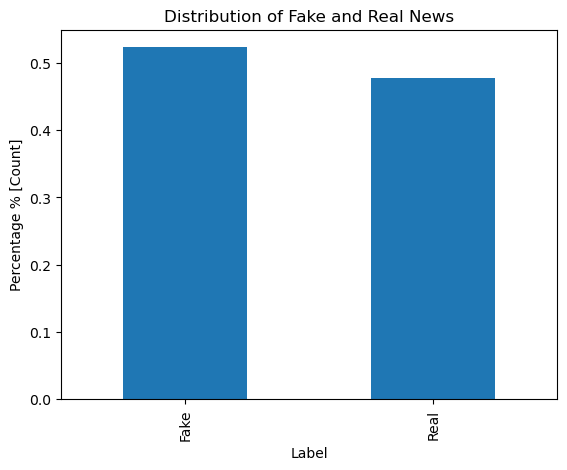

In [34]:
# visualize the classs
df["label"].value_counts(normalize=True).plot(kind="bar")

plt.title("Distribution of Fake and Real News")
plt.xlabel("Label")
plt.ylabel("Percentage % [Count]")
plt.xticks([0, 1], ["Fake", "Real"])

plt.show()

In [41]:
# change date format
df["date"].sample(20, random_state=42)



22216      January 29, 2017
27917     December 13, 2016
25007       October 3, 2017
1377           Aug 25, 2017
32476          Sep 26, 2016
5766           Jul 27, 2017
16230         March 9, 2016
20911     December 12, 2017
35838    September 16, 2016
33155      October 26, 2016
30458     November 13, 2017
12038          Mar 29, 2017
36687     December 21, 2017
36271           Dec 5, 2017
15135          Dec 11, 2015
31743     December 16, 2016
20629         July 28, 2017
1570           May 31, 2017
1219         March 30, 2017
34466        March 10, 2016
Name: date, dtype: object

In [42]:
# since the data mixes format ,will try to accommodate all fornat
df["date"] = df["date"].str.strip()

df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    errors="coerce"
)

In [43]:
df.describe(include = "all")

,title,text,subject,date,label
count,44898,44898,44898,44888,44898.000000
unique,38729,38646,8,NaN,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,NaN,NaN
freq,14,627,11272,NaN,NaN
mean,NaN,NaN,NaN,2017-01-30 00:29:13.484227584,0.522985
min,NaN,NaN,NaN,2015-03-31 00:00:00,0.000000
25%,NaN,NaN,NaN,2016-07-09 00:00:00,0.000000
50%,NaN,NaN,NaN,2017-03-05 00:00:00,1.000000
75%,NaN,NaN,NaN,2017-09-24 00:00:00,1.000000
max,NaN,NaN,NaN,2018-02-19 00:00:00,1.000000


In [44]:
df.head()

,title,text,subject,date,label
0,It’s Really Happening: Trump Adviser Lays Out...,"Well, that didn t take long. In the short time...",News,2016-11-16,1
1,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,2017-09-11,0
2,Trump says churches should get FEMA funds for ...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,2017-09-09,0
3,Trump Loves To Say The New York Times Is ‘Fai...,Print journalism and longstanding papers have ...,News,2017-08-07,1
4,House Speaker Ryan briefed Trump on healthcare...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,2017-03-24,0


In [47]:
# save the data to preprocesssed
df.to_csv("/Users/EXOTISCH TECH/Desktop/Fake-Real-News-Project/data/processed/news.csv", index=False)